# Differentiable vehicle handling: yaw-plane dynamics and design sensitivity

Vehicle *handling* lives in the yaw plane: how the car's yaw rate and sideslip
respond to steering. This notebook builds a yaw-plane (single-track) handling model
with a **Pacejka magic-formula tyre** in Jaxonomy, validates its step-steer
response against the classical linear understeer theory, and then does the thing a
JAX-native simulator makes easy and a black-box simulator does not: **differentiates
the handling response with respect to a design parameter**. We compute
$\partial(\text{steady yaw rate})/\partial(\text{rear tyre stiffness})$ by
forward- and reverse-mode autodiff *through the simulation* and confirm it against
finite differences — a gradient a chassis engineer can hand straight to an optimiser.

## Prerequisites
- Jaxonomy basics (`LeafSystem`, `simulate`), and `simulate_jacfwd` / `jax.grad`
  for differentiating through a run.
- Handling vocabulary: slip angle $\alpha$, yaw rate $r$, understeer gradient.

> **Out of scope, on purpose.** Longitudinal load transfer, roll/pitch, suspension
> compliance, and combined-slip (braking-in-a-corner) are excluded. The yaw-plane
> model is the right altitude for steady handling balance and its sensitivities;
> the lap-time tutorial (`f1_part_1`) carries a fuller vehicle.


## 1. Vehicle and Pacejka tyre parameters

A mid-size sedan. Front and rear tyres have different stiffness factors so the car is **understeering** (the stable, road-car design): at the limit the front washes out before the rear, and yaw rate gain falls off with speed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
import jaxonomy
from jaxonomy import LeafSystem, simulate, SimulatorOptions
from jaxonomy.backend import numpy_api as npa

M, IZ = 1500.0, 2250.0              # mass [kg], yaw inertia [kg m^2]
L_F, L_R = 1.2, 1.5                 # CG to front / rear axle [m]
L = L_F + L_R
U = 25.0                            # forward speed [m/s] (~90 km/h), held constant
PC, PE, MU = 1.3, 0.97, 1.0         # Pacejka shape/curvature, peak friction
B_F, B_R = 8.0, 12.0               # Pacejka stiffness factor, front / rear
FZ_F = M * 9.81 * L_R / L           # static axle loads
FZ_R = M * 9.81 * L_F / L
C_F = B_F * PC * MU * FZ_F          # linear cornering stiffness = -dFy/dalpha|0
C_R = B_R * PC * MU * FZ_R
K_US = (M / L) * (L_R / C_F - L_F / C_R)   # understeer gradient [rad/(m/s^2)]
print(f"cornering stiffness:  C_f = {C_F:.0f} N/rad,  C_r = {C_R:.0f} N/rad")
print(f"understeer gradient K_us = {K_US:.5f} rad/(m/s^2)  ->  "
      f"{'understeer' if K_US>0 else 'oversteer'}")

cornering stiffness:  C_f = 85020 N/rad,  C_r = 102024 N/rad
understeer gradient K_us = 0.00327 rad/(m/s^2)  ->  understeer


## 2. The Pacejka magic-formula tyre

The lateral force is $F_y=-\mu F_z\sin\!\big(C\arctan(B\alpha - E(B\alpha-\arctan
B\alpha))\big)$ — linear in slip angle near zero, then saturating at $\mu F_z$. The
near-zero slope is the **cornering stiffness** $C_\alpha=BCD$ that the linear theory
uses; the saturation is what makes the limit behaviour nonlinear.

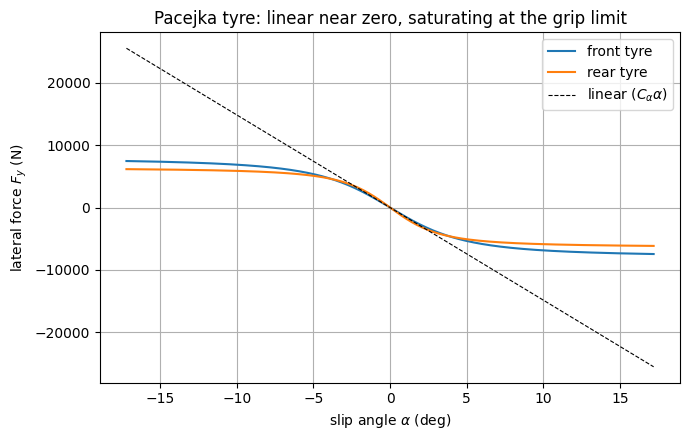

In [2]:
def pacejka(alpha, Fz, B):
    x = B * alpha
    return -MU * Fz * npa.sin(PC * npa.arctan(x - PE * (x - npa.arctan(x))))

a = np.linspace(-0.3, 0.3, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.degrees(a), [pacejka(x, FZ_F, B_F) for x in a], label="front tyre")
ax.plot(np.degrees(a), [pacejka(x, FZ_R, B_R) for x in a], label="rear tyre")
ax.plot(np.degrees(a), [-C_F * x for x in a], "k--", lw=0.8, label="linear ($C_\\alpha\\alpha$)")
ax.set_xlabel("slip angle $\\alpha$ (deg)"); ax.set_ylabel("lateral force $F_y$ (N)")
ax.set_title("Pacejka tyre: linear near zero, saturating at the grip limit")
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

## 3. The yaw-plane vehicle as a `LeafSystem`

Two states: lateral velocity $v$ and yaw rate $r$ (forward speed $U$ held constant). Steering $\delta$ and a rear-stiffness scale $k_r$ are **dynamic parameters** — a constant steer applied from $t=0$ is the standard *step-steer* handling test, and exposing $k_r$ as a parameter is what lets us differentiate the response with respect to it.

In [3]:
class Vehicle(LeafSystem):
    '''Yaw-plane single-track model. States [v, r]; params delta (steer), k_r.'''
    def __init__(self):
        super().__init__()
        self.declare_dynamic_parameter("delta", jnp.array(0.0))
        self.declare_dynamic_parameter("k_r", jnp.array(1.0))
        self.declare_continuous_state(default_value=jnp.array([0.0, 0.0]), ode=self.ode)
        self.declare_continuous_state_output(name="vr")
    def ode(self, time, state, **p):
        v, r = state.continuous_state
        d, k_r = p["delta"], p["k_r"]
        a_f = npa.arctan2(v + L_F * r, U) - d
        a_r = npa.arctan2(v - L_R * r, U)
        Fy_f = pacejka(a_f, FZ_F, B_F)
        Fy_r = k_r * pacejka(a_r, FZ_R, B_R)
        return npa.array([(Fy_f + Fy_r) / M - U * r,
                          (L_F * Fy_f - L_R * Fy_r) / IZ])

veh = Vehicle()
def make_ctx(args):
    delta, k_r = args
    ctx = veh.create_context()
    ctx.parameters["delta"] = delta; ctx.parameters["k_r"] = k_r
    return ctx

def run(delta, k_r=1.0, t_end=4.0):
    res = simulate(veh, make_ctx((jnp.array(delta), jnp.array(k_r))), (0.0, t_end),
                   options=SimulatorOptions(max_minor_step_size=0.01, buffer_length=4000),
                   recorded_signals={"vr": veh.output_ports[0]})
    return res

## 4. Step-steer response

Apply a 3° steer from $t=0$ and watch the yaw rate and sideslip $\beta=\arctan(v/U)$ build to steady cornering, with lateral acceleration $a_y=U\,r$.

22:03:11.563 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:11.564 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


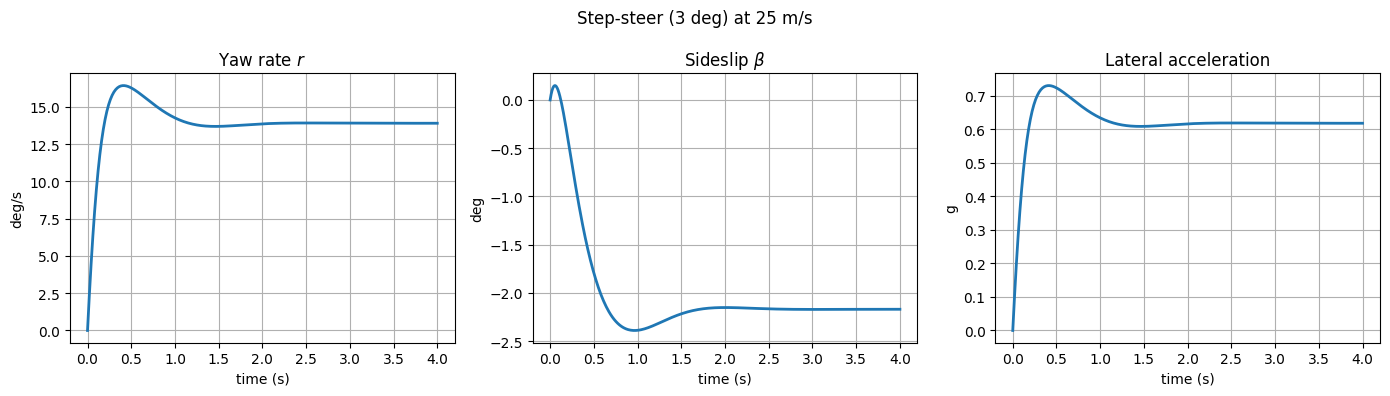

steady yaw rate 13.90 deg/s, sideslip -2.17 deg, lateral accel 0.62 g


In [4]:
res = run(np.radians(3.0))
t = np.asarray(res.time); v = res.outputs["vr"][:, 0]; r = res.outputs["vr"][:, 1]
beta = np.degrees(np.arctan2(v, U)); ay = U * r

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(t, np.degrees(r), lw=2); ax[0].set_title("Yaw rate $r$"); ax[0].set_ylabel("deg/s")
ax[1].plot(t, beta, lw=2); ax[1].set_title("Sideslip $\\beta$"); ax[1].set_ylabel("deg")
ax[2].plot(t, ay / 9.81, lw=2); ax[2].set_title("Lateral acceleration"); ax[2].set_ylabel("g")
for a_ in ax: a_.set_xlabel("time (s)"); a_.grid(True)
plt.suptitle("Step-steer (3 deg) at 25 m/s"); plt.tight_layout()
plt.savefig("media/vehicle_handling_autodiff.png", dpi=130); plt.show()
print(f"steady yaw rate {np.degrees(r[-1]):.2f} deg/s, sideslip {beta[-1]:.2f} deg, "
      f"lateral accel {ay[-1]/9.81:.2f} g")

## 5. Validation gate: the linear understeer model

At low lateral acceleration the Pacejka tyre is in its linear range, so the
nonlinear sim must reproduce the classical steady-state yaw-rate gain
$r/\delta = U/(L + K_{us}U^2)$. We check a small (1°) steer where $a_y$ stays well
under $0.3$ g.

In [5]:
delta_lin = np.radians(1.0)
r_lin = U * delta_lin / (L + K_US * U**2)
res1 = run(delta_lin)
r_nl = float(res1.outputs["vr"][-1, 1]); ay1 = U * r_nl
print(f"delta = 1 deg:  yaw rate  nonlinear = {r_nl:.5f} rad/s,  linear model = {r_lin:.5f} rad/s")
print(f"                error = {abs(r_nl-r_lin)/r_lin*100:.2f}%   (lateral accel {ay1/9.81:.2f} g)")
assert res1.time[0] == 0.0,                      "buffer overflow"
assert abs(r_nl - r_lin) / r_lin < 0.03,         "nonlinear steady yaw rate off the linear model"
print("\nVALIDATION PASSED: at low g the Pacejka model reproduces classical understeer theory.")

22:03:11.877 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:11.878 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


delta = 1 deg:  yaw rate  nonlinear = 0.09080 rad/s,  linear model = 0.09201 rad/s
                error = 1.32%   (lateral accel 0.23 g)

VALIDATION PASSED: at low g the Pacejka model reproduces classical understeer theory.


## 6. The differentiable beat: $\partial(\text{yaw rate})/\partial(\text{rear stiffness})$

Here is what JAX-native simulation buys a chassis engineer. The steady yaw rate is
the output of a *whole simulation*; we want its sensitivity to the rear tyre
stiffness scale $k_r$ — a real tuning knob (tyre choice, pressure). Rather than
re-running the sim at perturbed values, we differentiate **through** it:

- `simulate_jacfwd` — forward-mode Jacobian (best when few parameters);
- `jax.grad` — reverse-mode, on the same quantity.

Both must agree with a finite-difference check. The sign is physical: a stiffer
rear increases understeer, so it **lowers** the yaw-rate gain.

In [6]:
T = 4.0; delta = np.radians(1.0)
opts = SimulatorOptions(math_backend="jax", ode_solver_method="dopri5",
                        rtol=1e-9, atol=1e-11, max_major_steps=4000)
# forward mode through simulate_jacfwd (output = final yaw rate)
J = jaxonomy.simulate_jacfwd(veh, make_ctx, (0.0, T),
                             (jnp.array(delta), jnp.array(1.0)),
                             output_fn=lambda c: c.continuous_state[1], options=opts)
J_fwd = float(J[1])   # d(yaw rate)/d(k_r)

# reverse mode through jax.grad on the same scalar
def yaw_final(k_r):
    ctx = make_ctx((jnp.array(delta), k_r))
    g = SimulatorOptions(math_backend="jax", enable_autodiff=True, ode_solver_method="dopri5",
                         rtol=1e-9, atol=1e-11, max_major_steps=4000)
    return simulate(veh, ctx, (0.0, T), options=g).context.continuous_state[1]
J_rev = float(jax.grad(yaw_final)(jnp.array(1.0)))

# finite-difference reference
h = 1e-3
J_fd = float((yaw_final(jnp.array(1.0 + h)) - yaw_final(jnp.array(1.0 - h))) / (2 * h))

print(f"d(yaw rate)/d(k_r):")
print(f"  simulate_jacfwd (forward) = {J_fwd:.6e}")
print(f"  jax.grad        (reverse) = {J_rev:.6e}")
print(f"  central difference         = {J_fd:.6e}")
assert abs(J_fwd - J_fd) / abs(J_fd) < 5e-3, "forward-mode AD disagrees with FD"
assert abs(J_rev - J_fd) / abs(J_fd) < 5e-3, "reverse-mode AD disagrees with FD"
assert J_fd < 0, "stiffer rear should reduce yaw-rate gain (more understeer)"
print("\nAD MATCHES FD: the gradient through the simulation is exact and ready for an optimiser.")

22:03:12.084 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=dopri5, rtol=1e-09, atol=1e-11, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-09, atol=1e-11, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:12.511 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=dopri5, rtol=1e-09, atol=1e-11, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-09, atol=1e-11, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


22:03:13.175 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=dopri5, rtol=1e-09, atol=1e-11, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-09, atol=1e-11, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


22:03:13.278 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=dopri5, rtol=1e-09, atol=1e-11, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-09, atol=1e-11, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


d(yaw rate)/d(k_r):
  simulate_jacfwd (forward) = -8.235954e-02
  jax.grad        (reverse) = -8.235930e-02
  central difference         = -8.235995e-02

AD MATCHES FD: the gradient through the simulation is exact and ready for an optimiser.


Finally, a picture of the gradient as a design tangent: sweep $k_r$, plot the steady yaw-rate gain, and overlay the AD-computed slope at $k_r=1$. The tangent lies on the curve — that is the sensitivity, obtained without finite differencing.

22:03:13.393 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:13.393 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:13.515 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:13.516 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:13.636 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


...

22:03:14.124 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:14.294 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:14.295 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:14.416 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:14.416 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


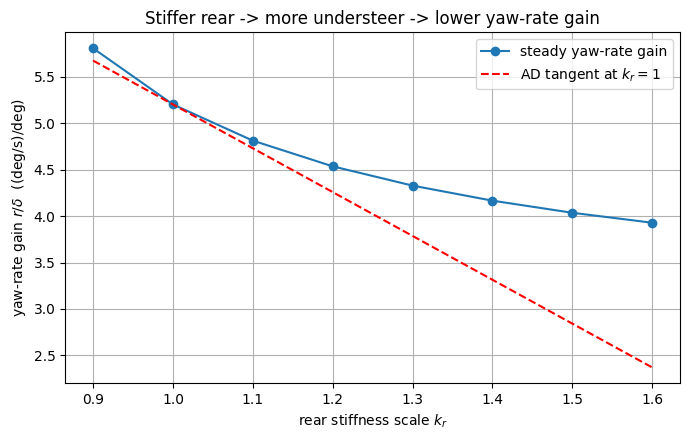

In [7]:
krs = np.linspace(0.9, 1.6, 8)   # stay in the stable understeer regime (oversteer covered in section 7)
gains = [np.degrees(run(delta, float(k)).outputs["vr"][-1, 1]) / np.degrees(delta) for k in krs]
g0 = np.degrees(run(delta, 1.0).outputs["vr"][-1, 1]) / np.degrees(delta)
slope = np.degrees(J_rev) / np.degrees(delta)    # d(gain)/d(k_r) in (deg/s)/deg per unit k_r
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(krs, gains, "o-", label="steady yaw-rate gain")
ax.plot(krs, g0 + slope * (krs - 1.0), "r--", label="AD tangent at $k_r=1$")
ax.set_xlabel("rear stiffness scale $k_r$"); ax.set_ylabel("yaw-rate gain $r/\\delta$  ((deg/s)/deg)")
ax.set_title("Stiffer rear -> more understeer -> lower yaw-rate gain"); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 7. Failure mode: too soft a rear turns understeer into oversteer

Understeer is stable; oversteer can go unstable above a critical speed. If we drop
the rear stiffness enough, $K_{us}$ goes negative (oversteer) and the step-steer
yaw rate, instead of settling, grows — the gradient we computed in §6 is exactly
the early warning of this balance shift.

In [8]:
def k_us(k_r):
    return (M / L) * (L_R / C_F - L_F / (k_r * C_R))
for k_r in [1.0, 0.5, 0.35]:
    r_end = float(run(np.radians(2.0), k_r, 6.0).outputs["vr"][-1, 1])
    kus = k_us(k_r)
    tag = "understeer (stable)" if kus > 0 else "OVERSTEER"
    print(f"k_r={k_r:.2f}:  K_us={kus:+.5f} -> {tag:20s} steady yaw rate {np.degrees(r_end):6.1f} deg/s")
print("\nAs the rear softens, K_us crosses zero into oversteer and the yaw rate balloons.")

22:03:14.586 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:14.587 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:14.710 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:14.711 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:03:14.840 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:03:14.840 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.01, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Vehicle(system_id=1, name='Vehicle_1_', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=0.01, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


k_r=1.00:  K_us=+0.00327 -> understeer (stable)  steady yaw rate   10.0 deg/s
k_r=0.50:  K_us=-0.00327 -> OVERSTEER            steady yaw rate  669.5 deg/s


k_r=0.35:  K_us=-0.00887 -> OVERSTEER            steady yaw rate  888.2 deg/s

As the rear softens, K_us crosses zero into oversteer and the yaw rate balloons.


## 8. Exercises
1. **Critical speed.** For an oversteering balance ($K_{us}<0$) the linear model is
   unstable above $U_{crit}=\sqrt{-L/K_{us}}$. Find it, then run the nonlinear sim
   just below and just above and watch the response diverge.
2. **Optimise the balance.** Use `jax.grad` from §6 in a one-line gradient step to
   find the $k_r$ that hits a *target* yaw-rate gain — a tiny design loop.
3. **Sensitivity map.** Extend `simulate_jacfwd` to differentiate the yaw rate
   w.r.t. *both* axle stiffnesses and the CG position; which knob moves the balance
   most per unit change?
4. **Limit handling.** Push the steer to 8–10° so the front tyre saturates; the
   linear gate no longer holds — measure where the nonlinear gain departs from it.

## 9. Key takeaways
- A two-state **yaw-plane model with a Pacejka tyre** captures steady handling
  balance and reduces to classical understeer theory at low g — validated, not
  asserted.
- Because the model is a Jaxonomy `LeafSystem`, **`jax.grad` / `simulate_jacfwd`
  flow through the whole simulation**, giving exact design sensitivities
  ($\partial r/\partial k_r$) — matched to finite differences — that a black-box
  simulator cannot provide.
- That gradient is also a **stability early-warning**: it tracks the understeer
  gradient as a soft rear pushes the car toward oversteer.

## References
- H. B. Pacejka, *Tyre and Vehicle Dynamics* — the magic-formula tyre.
- T. D. Gillespie, *Fundamentals of Vehicle Dynamics* — understeer gradient and the
  $r/\delta = U/(L+K_{us}U^2)$ steady-state relation.
